<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter2_Supervised%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 - Supervised Learning

**Book Reference:** *Introduction to Machine Learning with Python* — Andreas C. Müller & Sarah Guido

Notebook ini merangkum dan mereproduksi materi **Chapter 2: Supervised Learning** dari buku *Introduction to Machine Learning with Python*.  
Fokus bab ini adalah memahami konsep **supervised learning**, **generalization**, **overfitting**, **underfitting**, dan implementasi beberapa algoritma supervised learning utama seperti:

- k-Nearest Neighbors (k-NN)
- Linear Models for Classification
- Logistic Regression
- Linear Models for Multi-class Classification
- Naive Bayes
- Decision Trees
- Random Forest
- Gradient Boosting

Notebook ini dibuat dalam format **ringkasan teori + reproduksi kode + interpretasi hasil** agar dapat dijalankan di Google Colab dan hasilnya dapat tampil dengan baik di GitHub.

## Identitas Mahasiswa

**Nama:** Naufal Alif Abyan  
**NIM:** 101032300032  
**Mata Kuliah:** Machine Learning  
**Tugas:** Reproduksi & Ringkasan Buku *Introduction to Machine Learning with Python*  
**Bab:** Chapter 2 - Supervised Learning

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_style("whitegrid")

print("Library berhasil di-import.")

Library berhasil di-import.


# 1. Introduction to Supervised Learning

Pada **supervised learning**, model dilatih menggunakan **data berlabel**.  
Artinya, setiap data latih memiliki **fitur (input)** dan **target (output)**.

Contoh:
- Input: ukuran bunga, panjang kelopak, lebar kelopak
- Output: jenis bunga

Tujuan supervised learning adalah membangun model yang mampu **belajar hubungan antara fitur dan target**, lalu **memprediksi target untuk data baru** yang belum pernah dilihat sebelumnya.

Secara umum, supervised learning terbagi menjadi dua kategori utama:

1. **Classification**  
   Digunakan ketika target berupa kategori / label diskrit.  
   Contoh:
   - email spam atau bukan spam
   - transaksi fraud atau tidak fraud
   - tumor ganas atau jinak

2. **Regression**  
   Digunakan ketika target berupa nilai numerik kontinu.  
   Contoh:
   - prediksi harga rumah
   - prediksi suhu
   - prediksi tahun rilis lagu

Pada Chapter 2 buku ini, fokus utama adalah **supervised learning untuk classification**.

# 2. Generalization, Overfitting, and Underfitting

Tujuan utama machine learning **bukan sekadar mendapatkan skor tinggi pada data training**, tetapi **mampu bekerja dengan baik pada data baru**. Kemampuan ini disebut **generalization**.

## 2.1 Generalization
Generalization adalah kemampuan model untuk membuat prediksi yang baik pada data yang **tidak digunakan saat training**.

## 2.2 Overfitting
Overfitting terjadi ketika model terlalu “menghafal” data training, termasuk noise atau pola kebetulan yang sebenarnya tidak umum.  
Akibatnya:
- performa training sangat tinggi
- performa test/validation lebih buruk

Ciri umum overfitting:
- model terlalu kompleks
- jumlah parameter terlalu banyak
- data sedikit tetapi model sangat fleksibel

## 2.3 Underfitting
Underfitting terjadi ketika model terlalu sederhana sehingga tidak mampu menangkap pola penting pada data.

Akibatnya:
- performa training buruk
- performa test juga buruk

## 2.4 Hubungan dengan Model Complexity
Secara umum:
- model terlalu sederhana → **underfitting**
- model terlalu kompleks → **overfitting**
- model dengan kompleksitas yang pas → **generalization terbaik**

Pada bagian berikutnya, kita akan melihat bagaimana konsep ini muncul pada beberapa algoritma supervised learning.

# 3. Dataset yang Digunakan: Breast Cancer Wisconsin Dataset

Pada reproduksi Chapter 2, buku menggunakan **Breast Cancer Wisconsin dataset** dari scikit-learn.

Dataset ini berisi fitur-fitur numerik yang menggambarkan karakteristik sel hasil pemeriksaan tumor payudara.  
Targetnya adalah klasifikasi:

- **0 = malignant** (ganas)
- **1 = benign** (jinak)

Dataset ini sangat cocok untuk demonstrasi supervised learning classification karena:
- ukuran dataset tidak terlalu besar
- semua fitur numerik
- target berupa klasifikasi biner
- cukup realistis untuk studi kasus medis

In [5]:
# LOAD DATASET
cancer = load_breast_cancer()

print("Keys pada dataset:")
print(cancer.keys())

Keys pada dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
# Menampilkan informasi dasar dataset
print("Nama dataset:", cancer["DESCR"].split("\n")[0])
print("Shape data:", cancer.data.shape)
print("Shape target:", cancer.target.shape)
print("Target names:", cancer.target_names)

Nama dataset: .. _breast_cancer_dataset:
Shape data: (569, 30)
Shape target: (569,)
Target names: ['malignant' 'benign']


In [7]:
# Membuat DataFrame agar lebih mudah dibaca
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer["target"] = cancer.target

print("5 data pertama:")
display(df_cancer.head())

5 data pertama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
print("Informasi dataset:")
df_cancer.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothn

In [9]:
print("Distribusi target:")
print(df_cancer["target"].value_counts())
print("\n0 = malignant, 1 = benign")

Distribusi target:
target
1    357
0    212
Name: count, dtype: int64

0 = malignant, 1 = benign


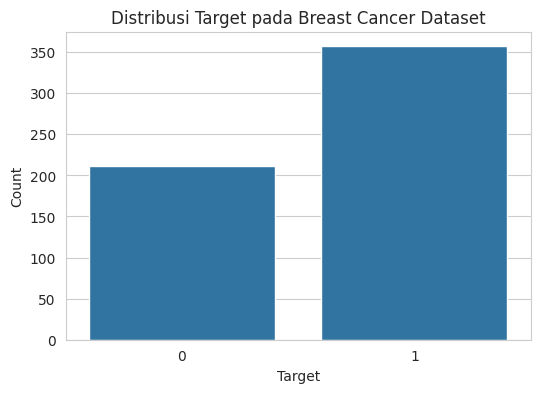

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_cancer["target"])
plt.title("Distribusi Target pada Breast Cancer Dataset")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## Interpretasi Awal Dataset

Dari output di atas, kita dapat melihat bahwa:
- dataset memiliki banyak fitur numerik
- target terdiri dari dua kelas: malignant dan benign
- distribusi kelas cukup baik untuk demonstrasi klasifikasi

Selanjutnya, kita akan membagi data menjadi:
- **training set** → digunakan untuk melatih model
- **test set** → digunakan untuk mengevaluasi generalization model

In [11]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=66
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (426, 30)
X_test shape : (143, 30)
y_train shape: (426,)
y_test shape : (143,)


# 4. k-Nearest Neighbors (k-NN)

k-Nearest Neighbors (k-NN) adalah algoritma supervised learning yang sangat intuitif.

## Cara kerja k-NN
Untuk memprediksi label suatu data baru:
1. hitung jarak data baru ke seluruh data training
2. ambil **k tetangga terdekat**
3. lakukan voting label mayoritas

Jika:
- mayoritas tetangga adalah benign → prediksi benign
- mayoritas tetangga adalah malignant → prediksi malignant

## Pengaruh nilai k
Nilai **k** menentukan kompleksitas model:
- **k kecil** → model sangat sensitif terhadap data lokal → cenderung **overfitting**
- **k besar** → keputusan lebih halus/sederhana → bisa **underfitting**

Karena itu, k-NN adalah contoh yang sangat baik untuk mempelajari trade-off antara **overfitting** dan **underfitting**.

In [12]:
# KNN - MODEL DENGAN DEFAULT PARAMETER
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

train_score_knn = knn.score(X_train, y_train)
test_score_knn = knn.score(X_test, y_test)

print("k-NN (default)")
print(f"Training accuracy: {train_score_knn:.3f}")
print(f"Test accuracy    : {test_score_knn:.3f}")

k-NN (default)
Training accuracy: 0.948
Test accuracy    : 0.923


## Analisis k-NN Default

Model k-NN default pada scikit-learn menggunakan nilai `n_neighbors=5`.  
Namun, untuk memahami hubungan antara kompleksitas model dan performa, kita perlu menguji beberapa nilai `k`.

Pada eksperimen berikut, kita akan mencoba `k = 1` sampai `k = 10`, lalu membandingkan:
- **training accuracy**
- **test accuracy**

Dengan begitu, kita bisa melihat:
- kapan model terlalu kompleks
- kapan model terlalu sederhana
- nilai k mana yang memberikan generalization terbaik

In [13]:
# ANALISIS PENGARUH NILAI K PADA KNN
training_accuracy = []
test_accuracy = []

neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)

    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

results_knn = pd.DataFrame({
    "n_neighbors": list(neighbors_settings),
    "training_accuracy": training_accuracy,
    "test_accuracy": test_accuracy
})

display(results_knn)

,n_neighbors,training_accuracy,test_accuracy
0,1,1.000000,0.902098
1,2,0.976526,0.888112
2,3,0.957746,0.923077
3,4,0.955399,0.923077
4,5,0.948357,0.923077
5,6,0.946009,0.937063
6,7,0.943662,0.930070
7,8,0.941315,0.930070
8,9,0.934272,0.916084
9,10,0.938967,0.916084


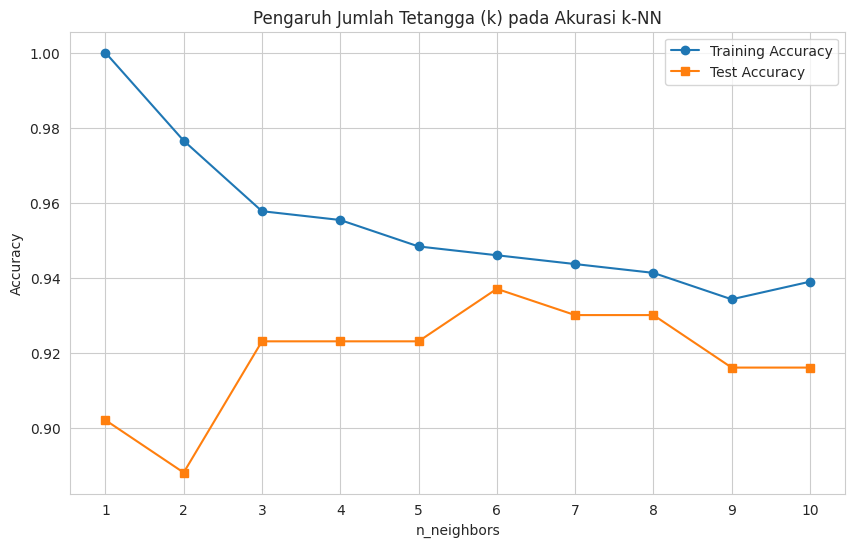

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, training_accuracy, marker="o", label="Training Accuracy")
plt.plot(neighbors_settings, test_accuracy, marker="s", label="Test Accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.title("Pengaruh Jumlah Tetangga (k) pada Akurasi k-NN")
plt.xticks(list(neighbors_settings))
plt.legend()
plt.show()

## Interpretasi Hasil k-NN

Grafik di atas menunjukkan hubungan antara jumlah tetangga (`n_neighbors`) dan akurasi model.

### Saat `k = 1`
Model hanya melihat **1 tetangga terdekat**.  
Akibatnya:
- boundary keputusan sangat fleksibel
- training accuracy biasanya sangat tinggi
- model mudah menghafal data training
- risiko **overfitting** tinggi

### Saat `k` semakin besar
Model mempertimbangkan lebih banyak tetangga, sehingga:
- keputusan menjadi lebih stabil
- boundary lebih halus
- model menjadi lebih sederhana

### Trade-off
- **k terlalu kecil** → overfitting
- **k terlalu besar** → underfitting
- **k menengah** → biasanya memberikan generalization terbaik

Dengan eksperimen ini, kita bisa melihat secara langsung bahwa pemilihan hyperparameter sangat memengaruhi performa model.

In [15]:
# Menentukan nilai k terbaik berdasarkan test accuracy
best_idx = np.argmax(test_accuracy)
best_k = list(neighbors_settings)[best_idx]
best_test_score = test_accuracy[best_idx]

print(f"Nilai k terbaik berdasarkan test accuracy: {best_k}")
print(f"Test accuracy terbaik: {best_test_score:.3f}")

Nilai k terbaik berdasarkan test accuracy: 6
Test accuracy terbaik: 0.937


In [16]:
# Melatih ulang model dengan k terbaik
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

y_pred_knn = best_knn.predict(X_test)

print("Classification Report - Best k-NN")
print(classification_report(y_test, y_pred_knn, target_names=cancer.target_names))

Classification Report - Best k-NN
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        53
      benign       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



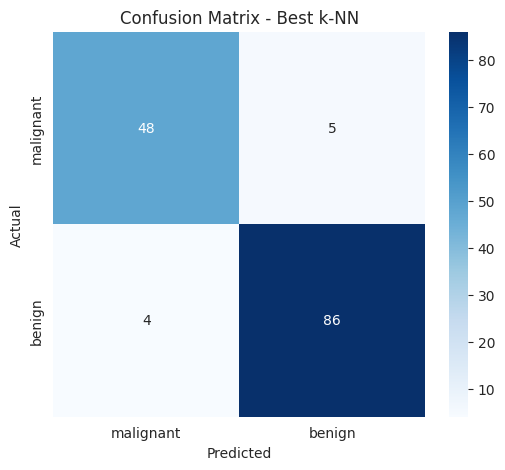

In [17]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Best k-NN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. Linear Models for Classification

Setelah melihat k-NN, kita beralih ke **linear models** untuk klasifikasi.

Linear model berusaha memisahkan kelas menggunakan **kombinasi linear dari fitur**.  
Untuk kasus biner, model mencoba membuat **decision boundary** yang memisahkan dua kelas.

Secara umum, model linear memiliki bentuk:

\[
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
\]

di mana:
- \(x_i\) = fitur
- \(w_i\) = bobot/koefisien
- \(b\) = bias/intercept

Dalam klasifikasi, hasil kombinasi linear ini kemudian digunakan untuk menentukan kelas.

Pada Chapter 2, dua model linear utama yang dibahas adalah:
1. **Logistic Regression**
2. **Linear Support Vector Machines (Linear SVM)**

Di notebook ini kita fokus pada **Logistic Regression**, karena itu yang paling umum digunakan dan sangat penting untuk dipahami.

# 6. Logistic Regression

Meskipun namanya mengandung kata **Regression**, Logistic Regression adalah **algoritma klasifikasi**, bukan regresi.

Model ini digunakan untuk memprediksi probabilitas suatu data termasuk ke kelas tertentu.  
Untuk klasifikasi biner, Logistic Regression menghasilkan probabilitas, lalu mengubahnya menjadi label kelas.

## Regularization dan Parameter C
Salah satu hyperparameter terpenting pada Logistic Regression adalah **C**.

- **C besar** → regularization lemah → model lebih bebas menyesuaikan data → risiko **overfitting**
- **C kecil** → regularization kuat → model dipaksa lebih sederhana → risiko **underfitting**

Artinya, `C` mengontrol kompleksitas model.

Kita akan membandingkan tiga model:
- `C = 1` (default)
- `C = 100` (lebih kompleks)
- `C = 0.01` (lebih sederhana)

In [18]:
# LOGISTIC REGRESSION - C = 1 (DEFAULT)
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

print("Logistic Regression (C=1)")
print(f"Training set score: {logreg.score(X_train, y_train):.3f}")
print(f"Test set score    : {logreg.score(X_test, y_test):.3f}")

Logistic Regression (C=1)
Training set score: 0.979
Test set score    : 0.944


In [19]:
# LOGISTIC REGRESSION - C = 100
logreg100 = LogisticRegression(C=100, max_iter=10000)
logreg100.fit(X_train, y_train)

print("Logistic Regression (C=100)")
print(f"Training set score: {logreg100.score(X_train, y_train):.3f}")
print(f"Test set score    : {logreg100.score(X_test, y_test):.3f}")

Logistic Regression (C=100)
Training set score: 0.986
Test set score    : 0.965


In [20]:
# LOGISTIC REGRESSION - C = 0.01
logreg001 = LogisticRegression(C=0.01, max_iter=10000)
logreg001.fit(X_train, y_train)

print("Logistic Regression (C=0.01)")
print(f"Training set score: {logreg001.score(X_train, y_train):.3f}")
print(f"Test set score    : {logreg001.score(X_test, y_test):.3f}")

Logistic Regression (C=0.01)
Training set score: 0.960
Test set score    : 0.937


## Interpretasi Logistic Regression

Dari tiga model di atas, kita dapat melihat pengaruh parameter **C** terhadap performa.

### 1. `C = 100`
Regularization lemah → model lebih fleksibel.  
Model berusaha menyesuaikan data training dengan lebih kuat, sehingga bisa meningkatkan training score.  
Namun, jika terlalu fleksibel, risiko **overfitting** meningkat.

### 2. `C = 1`
Ini adalah nilai default yang sering memberikan hasil cukup baik sebagai baseline.

### 3. `C = 0.01`
Regularization kuat → koefisien dipaksa mendekati nol → model lebih sederhana.  
Jika terlalu sederhana, model dapat kehilangan pola penting → **underfitting**.

Jadi, seperti pada k-NN, kita kembali melihat trade-off antara:
- model terlalu fleksibel
- model terlalu sederhana

In [21]:
# Ringkasan skor Logistic Regression
logreg_results = pd.DataFrame({
    "Model": ["LogReg C=1", "LogReg C=100", "LogReg C=0.01"],
    "Train Accuracy": [
        logreg.score(X_train, y_train),
        logreg100.score(X_train, y_train),
        logreg001.score(X_train, y_train)
    ],
    "Test Accuracy": [
        logreg.score(X_test, y_test),
        logreg100.score(X_test, y_test),
        logreg001.score(X_test, y_test)
    ]
})

display(logreg_results)

,Model,Train Accuracy,Test Accuracy
0,LogReg C=1,0.978873,0.944056
1,LogReg C=100,0.985915,0.965035
2,LogReg C=0.01,0.960094,0.937063


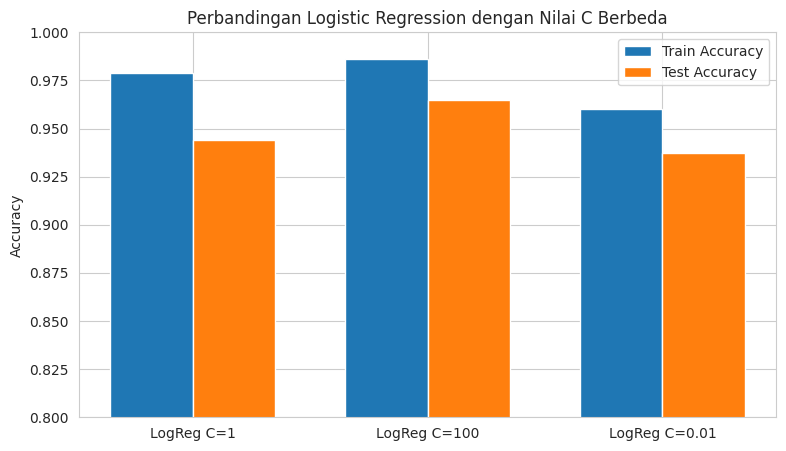

In [22]:
plt.figure(figsize=(9, 5))

x = np.arange(len(logreg_results))
width = 0.35

plt.bar(x - width/2, logreg_results["Train Accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, logreg_results["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, logreg_results["Model"])
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Perbandingan Logistic Regression dengan Nilai C Berbeda")
plt.legend()
plt.show()

# 7. Interpreting Coefficients in Logistic Regression

Salah satu kelebihan model linear adalah **mudah diinterpretasikan**.  
Setiap fitur memiliki **koefisien** yang menunjukkan seberapa besar pengaruh fitur tersebut terhadap prediksi.

- Koefisien **positif** → fitur mendorong prediksi ke salah satu kelas
- Koefisien **negatif** → fitur mendorong prediksi ke kelas lainnya
- Nilai absolut koefisien besar → pengaruh fitur lebih kuat

Dengan melihat koefisien, kita bisa memahami fitur mana yang paling penting menurut model.

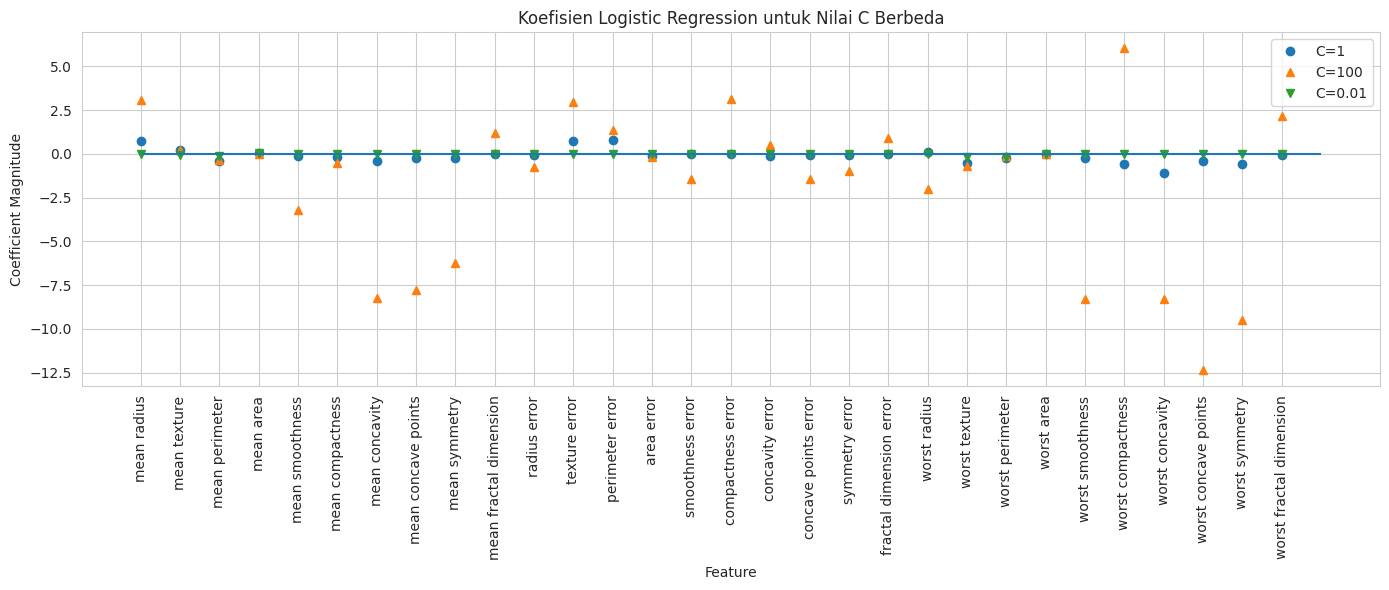

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(logreg.coef_.T, "o", label="C=1")
plt.plot(logreg100.coef_.T, "^", label="C=100")
plt.plot(logreg001.coef_.T, "v", label="C=0.01")

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient Magnitude")
plt.title("Koefisien Logistic Regression untuk Nilai C Berbeda")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
coef_df = pd.DataFrame({
    "feature": cancer.feature_names,
    "coef_C1": logreg.coef_[0],
    "coef_C100": logreg100.coef_[0],
    "coef_C001": logreg001.coef_[0]
})

display(coef_df.head(10))

,feature,coef_C1,coef_C100,coef_C001
0,mean radius,0.765016,3.056084,0.009505
1,mean texture,0.239172,0.245244,-0.045990
2,mean perimeter,-0.433498,-0.345077,-0.110059
3,mean area,0.040879,0.003491,0.030306
4,mean smoothness,-0.110385,-3.179467,-0.002061
5,mean compactness,-0.199876,-0.544090,-0.005983
6,mean concavity,-0.427611,-8.255478,-0.009163
7,mean concave points,-0.206711,-7.751447,-0.003829
8,mean symmetry,-0.221287,-6.228476,-0.003705
9,mean fractal dimension,-0.021924,1.177991,-0.000755


## Interpretasi Koefisien

Dari grafik dan tabel koefisien:
- semakin besar nilai **C**, model cenderung menghasilkan koefisien yang lebih besar
- semakin kecil nilai **C**, regularization semakin kuat, sehingga koefisien cenderung mengecil

Ini sangat penting karena menunjukkan bahwa regularization tidak hanya memengaruhi akurasi, tetapi juga **kompleksitas model** dan **interpretabilitas**.

# 8. Linear Models for Multi-class Classification

Supervised learning tidak hanya untuk klasifikasi biner, tetapi juga **multi-class classification**, yaitu ketika target memiliki lebih dari dua kelas.

Contoh:
- klasifikasi jenis bunga iris (setosa, versicolor, virginica)
- klasifikasi digit tulisan tangan (0 sampai 9)
- klasifikasi kategori berita

Pada linear models, salah satu pendekatan umum adalah **one-vs-rest**:
- buat satu classifier untuk tiap kelas
- tiap classifier membedakan “kelas ini” vs “bukan kelas ini”
- kelas dengan skor tertinggi dipilih sebagai prediksi akhir

Untuk mendemonstrasikan konsep ini, kita akan membuat dataset sintetis 2D dengan tiga kelas menggunakan `make_blobs`.

In [25]:
# MULTI-CLASS CLASSIFICATION DEMO
X, y = make_blobs(random_state=42)
X_train_blobs, X_test_blobs, y_train_blobs, y_test_blobs = train_test_split(
    X, y, random_state=0
)

logreg_multi = LogisticRegression(max_iter=10000)
logreg_multi.fit(X_train_blobs, y_train_blobs)

print("Training accuracy:", logreg_multi.score(X_train_blobs, y_train_blobs))
print("Test accuracy    :", logreg_multi.score(X_test_blobs, y_test_blobs))

Training accuracy: 1.0
Test accuracy    : 1.0


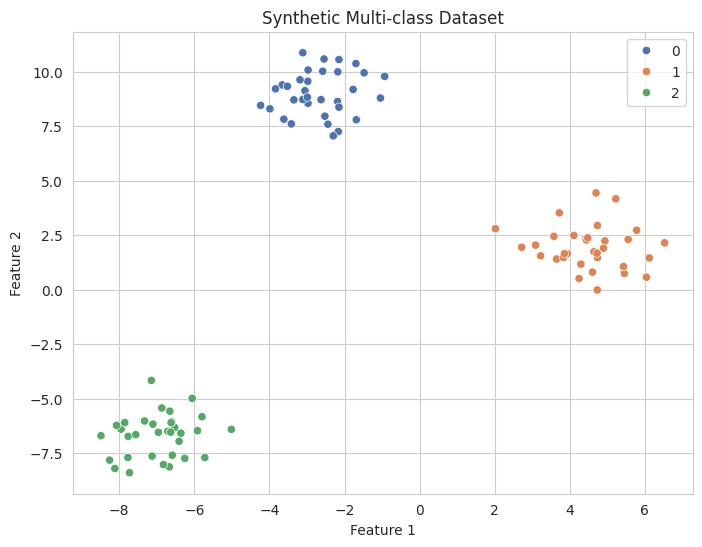

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="deep")
plt.title("Synthetic Multi-class Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [27]:
print("Koefisien model multi-class:")
print(logreg_multi.coef_)
print("\nIntercept:")
print(logreg_multi.intercept_)

Koefisien model multi-class:
[[-0.36841067  0.60575492]
 [ 0.7115879  -0.17250771]
 [-0.34317723 -0.43324721]]

Intercept:
[-1.58207497  1.85487338 -0.27279841]


## Interpretasi Multi-class Logistic Regression

Pada klasifikasi multi-class, model memiliki:
- satu set koefisien untuk setiap kelas
- satu intercept untuk setiap kelas

Setiap kelas memiliki “fungsi skor”-nya sendiri.  
Ketika data baru masuk, model menghitung skor untuk semua kelas, lalu memilih kelas dengan skor tertinggi.

Konsep ini memperluas ide klasifikasi biner ke kasus multi-kelas.

# 9. Naive Bayes

Naive Bayes adalah keluarga algoritma klasifikasi yang didasarkan pada **Teorema Bayes**.

Ide dasarnya adalah menghitung probabilitas suatu kelas berdasarkan fitur-fitur yang dimiliki sebuah data.

Disebut **naive** karena model ini membuat asumsi yang sangat kuat, yaitu:
> setiap fitur dianggap **independen** terhadap fitur lainnya, jika label kelas sudah diketahui.

Walaupun asumsi ini sering tidak realistis, Naive Bayes tetap berguna karena:
- sangat cepat
- sederhana
- sering cukup baik sebagai baseline
- efektif pada beberapa jenis data, terutama data teks

Di sini kita gunakan **Gaussian Naive Bayes**, yang cocok untuk fitur numerik kontinu.

In [28]:
# GAUSSIAN NAIVE BAYES
gnb = GaussianNB()
gnb.fit(X_train, y_train)

train_score_gnb = gnb.score(X_train, y_train)
test_score_gnb = gnb.score(X_test, y_test)

print("Gaussian Naive Bayes")
print(f"Training accuracy: {train_score_gnb:.3f}")
print(f"Test accuracy    : {test_score_gnb:.3f}")

Gaussian Naive Bayes
Training accuracy: 0.944
Test accuracy    : 0.923


In [29]:
y_pred_gnb = gnb.predict(X_test)

print("Classification Report - Gaussian Naive Bayes")
print(classification_report(y_test, y_pred_gnb, target_names=cancer.target_names))

Classification Report - Gaussian Naive Bayes
              precision    recall  f1-score   support

   malignant       0.92      0.87      0.89        53
      benign       0.92      0.96      0.94        90

    accuracy                           0.92       143
   macro avg       0.92      0.91      0.92       143
weighted avg       0.92      0.92      0.92       143



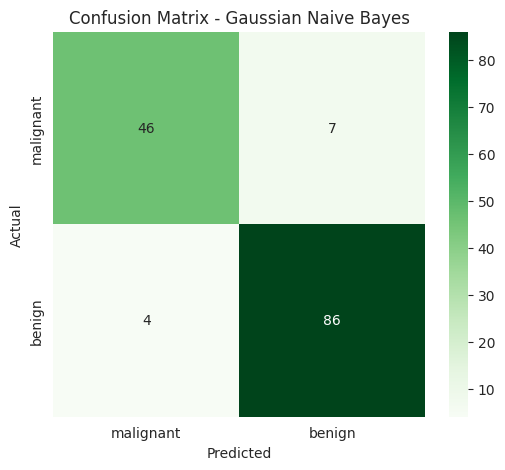

In [30]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Greens",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Interpretasi Naive Bayes

Naive Bayes biasanya:
- lebih sederhana daripada model ensemble
- lebih cepat daripada model kompleks
- tidak terlalu banyak hyperparameter

Namun, karena asumsi independensi antar fitur cukup kuat, performanya bisa kalah dibanding model yang lebih fleksibel seperti Random Forest atau Gradient Boosting.

Meski begitu, Naive Bayes tetap penting dipelajari karena:
1. merupakan baseline yang bagus
2. sangat cepat
3. membantu memahami klasifikasi probabilistik

# 10. Decision Trees

Decision Tree adalah model yang membagi data secara bertahap menggunakan aturan if-else berbentuk pohon.

Contoh sederhana:
- jika ukuran tumor > nilai tertentu → ke cabang kiri
- jika tidak → ke cabang kanan

Proses ini diulang terus sampai model dapat memisahkan data ke kelas-kelas tertentu.

## Kelebihan Decision Tree
- mudah dipahami
- mudah divisualisasikan
- dapat menangani hubungan non-linear
- tidak memerlukan scaling fitur

## Kekurangan
Decision Tree sangat mudah **overfitting**, terutama jika pohon dibiarkan tumbuh tanpa batas.

Karena itu, kita sering melakukan **pre-pruning**, misalnya dengan membatasi:
- `max_depth`
- `max_leaf_nodes`
- `min_samples_split`

Pada contoh berikut, kita bandingkan:
1. tree tanpa pembatasan
2. tree dengan `max_depth=4`

In [31]:
# DECISION TREE TANPA BATASAN
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

print("Decision Tree tanpa pembatasan")
print(f"Training accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy    : {tree.score(X_test, y_test):.3f}")

Decision Tree tanpa pembatasan
Training accuracy: 1.000
Test accuracy    : 0.895


In [32]:
# DECISION TREE DENGAN MAX_DEPTH=4
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_pruned.fit(X_train, y_train)

print("Decision Tree dengan max_depth=4")
print(f"Training accuracy: {tree_pruned.score(X_train, y_train):.3f}")
print(f"Test accuracy    : {tree_pruned.score(X_test, y_test):.3f}")

Decision Tree dengan max_depth=4
Training accuracy: 0.988
Test accuracy    : 0.902


## Interpretasi Decision Tree

### Tree tanpa batasan
Jika decision tree dibiarkan tumbuh bebas:
- model bisa membuat aturan yang sangat spesifik
- training accuracy bisa sangat tinggi, bahkan 100%
- model cenderung menghafal data training
- risiko overfitting sangat besar

### Tree dengan `max_depth=4`
Dengan membatasi kedalaman pohon:
- model menjadi lebih sederhana
- generalization biasanya lebih baik
- overfitting berkurang

Ini adalah contoh penting bahwa **kontrol kompleksitas model** dapat meningkatkan performa pada data baru.

In [33]:
tree_results = pd.DataFrame({
    "Model": ["Decision Tree (Full)", "Decision Tree (max_depth=4)"],
    "Train Accuracy": [
        tree.score(X_train, y_train),
        tree_pruned.score(X_train, y_train)
    ],
    "Test Accuracy": [
        tree.score(X_test, y_test),
        tree_pruned.score(X_test, y_test)
    ]
})

display(tree_results)

,Model,Train Accuracy,Test Accuracy
0,Decision Tree (Full),1.000000,0.895105
1,Decision Tree (max_depth=4),0.988263,0.902098


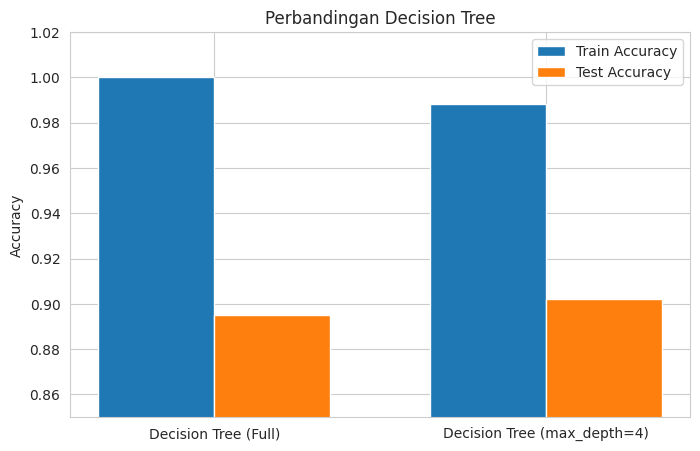

In [34]:
plt.figure(figsize=(8, 5))

x = np.arange(len(tree_results))
width = 0.35

plt.bar(x - width/2, tree_results["Train Accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, tree_results["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, tree_results["Model"])
plt.ylim(0.85, 1.02)
plt.ylabel("Accuracy")
plt.title("Perbandingan Decision Tree")
plt.legend()
plt.show()

In [35]:
# Menampilkan struktur aturan pohon yang sudah dipruning
tree_rules = export_text(tree_pruned, feature_names=list(cancer.feature_names))
print(tree_rules[:4000])  # dipotong agar output tidak terlalu panjang

|--- worst perimeter <= 105.95
|   |--- worst concave points <= 0.14
|   |   |--- worst radius <= 15.78
|   |   |   |--- class: 1
|   |   |--- worst radius >  15.78
|   |   |   |--- worst concavity <= 0.19
|   |   |   |   |--- class: 1
|   |   |   |--- worst concavity >  0.19
|   |   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst smoothness <= 0.17
|   |   |   |--- area error <= 20.99
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  20.99
|   |   |   |   |--- class: 0
|   |   |--- worst smoothness >  0.17
|   |   |   |--- class: 0
|--- worst perimeter >  105.95
|   |--- worst perimeter <= 114.45
|   |   |--- mean area <= 614.15
|   |   |   |--- class: 0
|   |   |--- mean area >  614.15
|   |   |   |--- mean texture <= 20.99
|   |   |   |   |--- class: 1
|   |   |   |--- mean texture >  20.99
|   |   |   |   |--- class: 0
|   |--- worst perimeter >  114.45
|   |   |--- worst compactness <= 0.12
|   |   |   |--- class: 1
|   |   |--- worst comp

## Feature Importance pada Decision Tree

Decision Tree juga dapat memberi tahu fitur mana yang paling penting melalui atribut `feature_importances_`.

Nilai feature importance menunjukkan seberapa besar kontribusi suatu fitur dalam membagi data di dalam pohon.
- nilai besar → fitur sangat penting
- nilai kecil / nol → fitur kurang berpengaruh dalam pohon

In [36]:
feature_importances_tree = pd.Series(
    tree_pruned.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False)

display(feature_importances_tree.head(10))

,0
worst perimeter,0.816894
mean area,0.054114
worst concave points,0.043759
mean texture,0.022201
worst smoothness,0.020099
worst concavity,0.017370
worst compactness,0.010182
area error,0.008685
perimeter error,0.003393
worst radius,0.003302


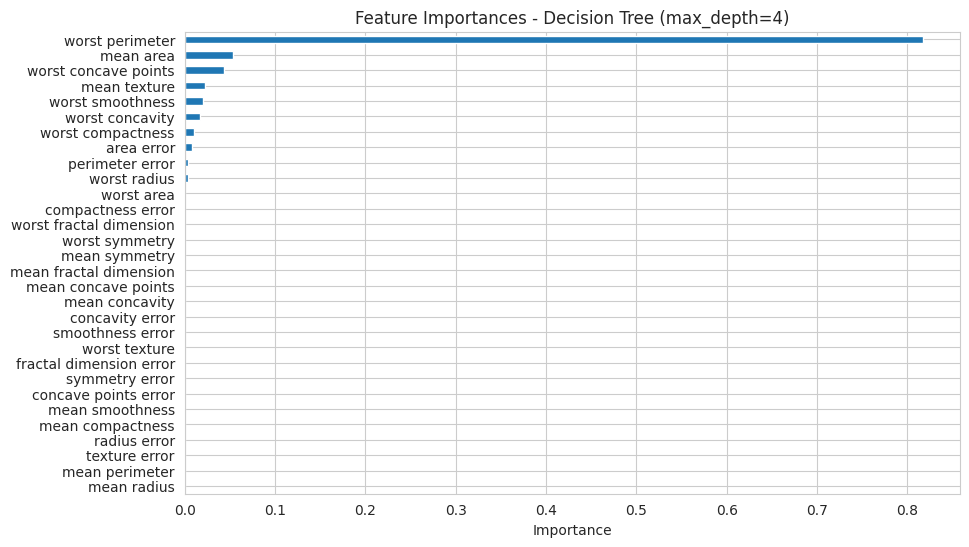

In [37]:
plt.figure(figsize=(10, 6))
feature_importances_tree.sort_values().plot(kind="barh")
plt.title("Feature Importances - Decision Tree (max_depth=4)")
plt.xlabel("Importance")
plt.show()

# 11. Random Forest

Random Forest adalah **ensemble** dari banyak decision tree.

Alih-alih menggunakan satu pohon saja, Random Forest membangun banyak pohon dengan variasi tertentu, lalu menggabungkan prediksi mereka.

## Ide utama Random Forest
Setiap tree dilatih pada versi data yang sedikit berbeda:
1. menggunakan sampel bootstrap dari data training
2. pada setiap split, hanya sebagian fitur yang dipertimbangkan

Dengan cara ini:
- tiap pohon menjadi berbeda
- prediksi antar pohon bisa saling melengkapi
- model lebih stabil daripada single decision tree
- overfitting berkurang dibanding decision tree tunggal

Random Forest adalah salah satu model klasik yang sangat kuat untuk data tabular.

In [38]:
# RANDOM FOREST
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

print("Random Forest")
print(f"Training accuracy: {forest.score(X_train, y_train):.3f}")
print(f"Test accuracy    : {forest.score(X_test, y_test):.3f}")

Random Forest
Training accuracy: 1.000
Test accuracy    : 0.958


In [39]:
y_pred_forest = forest.predict(X_test)

print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_forest, target_names=cancer.target_names))

Classification Report - Random Forest
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



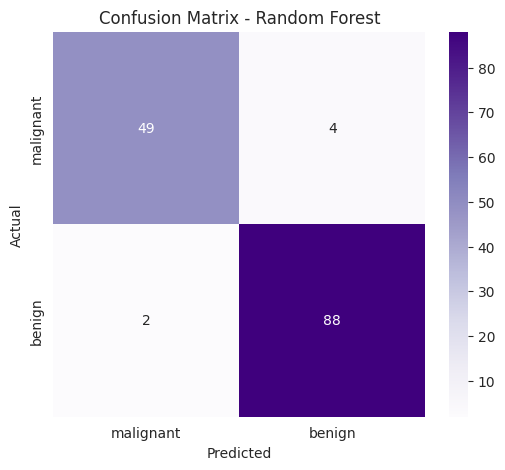

In [40]:
cm_forest = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_forest, annot=True, fmt="d", cmap="Purples",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
feature_importances_forest = pd.Series(
    forest.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False)

display(feature_importances_forest.head(10))

,0
worst perimeter,0.170089
worst concave points,0.113386
worst radius,0.103754
mean concave points,0.100563
worst area,0.087262
mean concavity,0.078837
mean perimeter,0.055322
mean area,0.046954
area error,0.032154
mean radius,0.029353


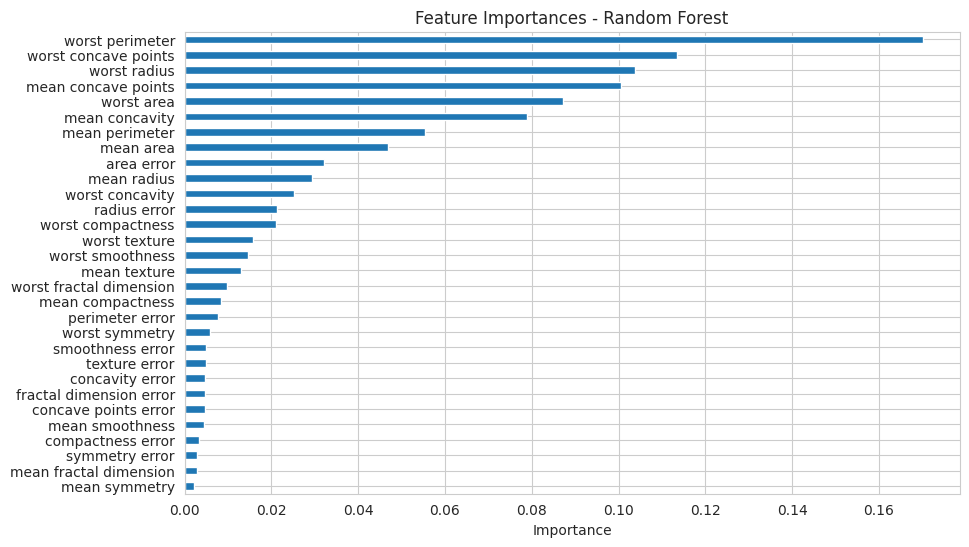

In [42]:
plt.figure(figsize=(10, 6))
feature_importances_forest.sort_values().plot(kind="barh")
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## Interpretasi Random Forest

Random Forest biasanya memberikan performa yang sangat baik karena:
- lebih stabil daripada single tree
- mampu menangkap pola non-linear
- relatif tahan terhadap overfitting dibanding pohon tunggal
- tidak memerlukan scaling fitur

Namun, ada trade-off:
- lebih sulit diinterpretasikan daripada satu decision tree
- training bisa lebih lambat
- model lebih “berat” dibanding Logistic Regression atau Naive Bayes

# 12. Gradient Boosting

Gradient Boosting juga merupakan metode ensemble berbasis decision tree, tetapi cara kerjanya berbeda dari Random Forest.

## Perbedaan inti
- **Random Forest** membangun banyak pohon **secara independen**, lalu menggabungkannya
- **Gradient Boosting** membangun pohon **secara berurutan**, di mana setiap pohon baru mencoba memperbaiki kesalahan pohon-pohon sebelumnya

Intuisi sederhananya:
1. model pertama membuat prediksi awal
2. model kedua fokus pada error yang belum diperbaiki
3. model ketiga memperbaiki sisa error lagi
4. proses berlanjut sampai model ensemble menjadi kuat

Gradient Boosting sering sangat kuat pada data tabular, tetapi hyperparameter harus diatur dengan hati-hati agar tidak overfit.

In [43]:
# GRADIENT BOOSTING - DEFAULT-ish EXAMPLE
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

print("Gradient Boosting")
print(f"Training accuracy: {gbrt.score(X_train, y_train):.3f}")
print(f"Test accuracy    : {gbrt.score(X_test, y_test):.3f}")

Gradient Boosting
Training accuracy: 1.000
Test accuracy    : 0.958


In [44]:
y_pred_gbrt = gbrt.predict(X_test)

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_pred_gbrt, target_names=cancer.target_names))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



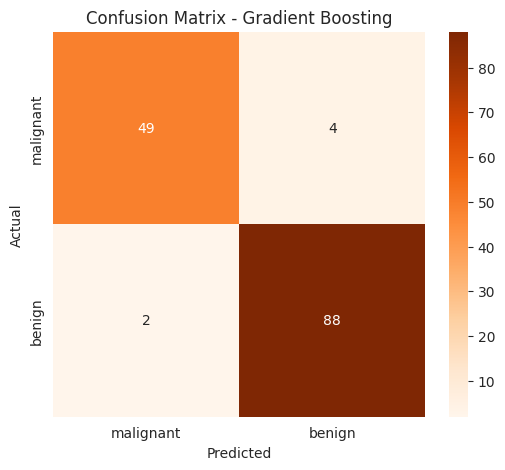

In [45]:
cm_gbrt = confusion_matrix(y_test, y_pred_gbrt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbrt, annot=True, fmt="d", cmap="Oranges",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
feature_importances_gbrt = pd.Series(
    gbrt.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False)

display(feature_importances_gbrt.head(10))

,0
worst perimeter,0.548623
worst radius,0.199217
worst concave points,0.063225
worst texture,0.043740
worst area,0.029323
mean concave points,0.022406
worst smoothness,0.017001
mean texture,0.016763
mean area,0.011023
worst compactness,0.007498


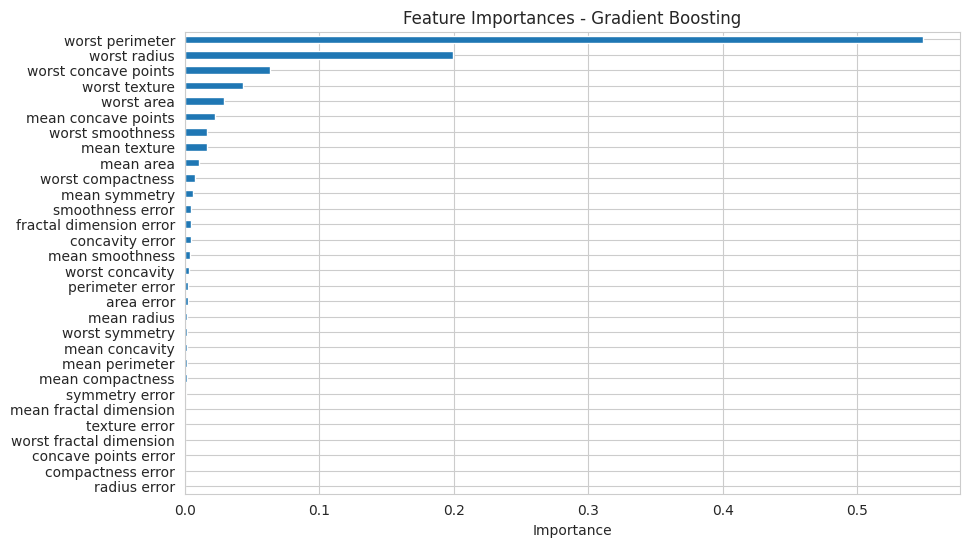

In [47]:
plt.figure(figsize=(10, 6))
feature_importances_gbrt.sort_values().plot(kind="barh")
plt.title("Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.show()

## Interpretasi Gradient Boosting

Gradient Boosting sering memberikan performa sangat tinggi pada dataset tabular karena:
- setiap tree baru fokus memperbaiki error sebelumnya
- model mampu membangun prediksi yang kuat secara bertahap

Namun, model ini juga bisa overfit jika:
- jumlah tree terlalu banyak
- learning rate tidak sesuai
- depth tree terlalu besar

Karena itu, gradient boosting sering membutuhkan tuning hyperparameter seperti:
- `n_estimators`
- `learning_rate`
- `max_depth`

# 13. Perbandingan Model-Model Supervised Learning

Setelah mencoba beberapa algoritma, sekarang kita bandingkan performa mereka pada dataset Breast Cancer:

- k-Nearest Neighbors
- Logistic Regression
- Gaussian Naive Bayes
- Decision Tree
- Random Forest
- Gradient Boosting

Tujuan bagian ini adalah melihat bahwa tidak ada satu model yang selalu terbaik untuk semua kasus.  
Setiap model memiliki trade-off masing-masing dalam hal:
- akurasi
- kompleksitas
- interpretabilitas
- risiko overfitting
- kecepatan training

In [48]:
# RINGKASAN PERBANDINGAN MODEL
summary_models = pd.DataFrame({
    "Model": [
        f"k-NN (k={best_k})",
        "Logistic Regression (C=1)",
        "Logistic Regression (C=100)",
        "Logistic Regression (C=0.01)",
        "Gaussian Naive Bayes",
        "Decision Tree (Full)",
        "Decision Tree (max_depth=4)",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train Accuracy": [
        best_knn.score(X_train, y_train),
        logreg.score(X_train, y_train),
        logreg100.score(X_train, y_train),
        logreg001.score(X_train, y_train),
        gnb.score(X_train, y_train),
        tree.score(X_train, y_train),
        tree_pruned.score(X_train, y_train),
        forest.score(X_train, y_train),
        gbrt.score(X_train, y_train)
    ],
    "Test Accuracy": [
        best_knn.score(X_test, y_test),
        logreg.score(X_test, y_test),
        logreg100.score(X_test, y_test),
        logreg001.score(X_test, y_test),
        gnb.score(X_test, y_test),
        tree.score(X_test, y_test),
        tree_pruned.score(X_test, y_test),
        forest.score(X_test, y_test),
        gbrt.score(X_test, y_test)
    ]
})

summary_models = summary_models.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(summary_models)

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression (C=100),0.985915,0.965035
1,Random Forest,1.000000,0.958042
2,Gradient Boosting,1.000000,0.958042
3,Logistic Regression (C=1),0.978873,0.944056
4,k-NN (k=6),0.946009,0.937063
5,Logistic Regression (C=0.01),0.960094,0.937063
6,Gaussian Naive Bayes,0.943662,0.923077
7,Decision Tree (max_depth=4),0.988263,0.902098
8,Decision Tree (Full),1.000000,0.895105


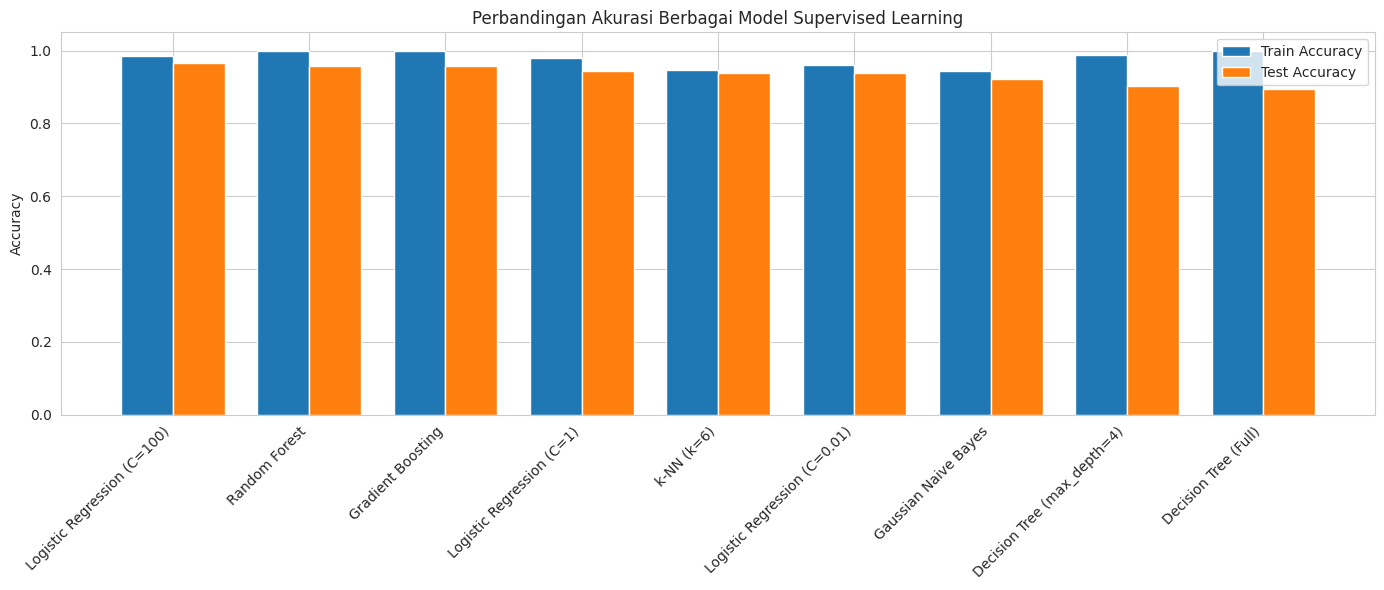

In [49]:
plt.figure(figsize=(14, 6))

x = np.arange(len(summary_models))
width = 0.38

plt.bar(x - width/2, summary_models["Train Accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, summary_models["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x, summary_models["Model"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Berbagai Model Supervised Learning")
plt.legend()
plt.tight_layout()
plt.show()

## Analisis Perbandingan Model

Dari tabel dan grafik perbandingan, kita bisa menarik beberapa pelajaran penting:

### 1. Model dengan training accuracy tinggi belum tentu terbaik
Contohnya, decision tree tanpa pembatasan bisa memiliki training accuracy sangat tinggi, tetapi belum tentu test accuracy terbaik. Ini menandakan **overfitting**.

### 2. Regularization membantu model linear
Pada Logistic Regression, pengaturan parameter `C` memengaruhi trade-off antara kompleksitas model dan kemampuan generalization.

### 3. Ensemble sering sangat kuat
Random Forest dan Gradient Boosting sering memberikan performa tinggi pada data tabular karena mereka menggabungkan banyak pohon untuk membangun model yang lebih stabil dan akurat.

### 4. Tidak ada model universal terbaik
Pilihan model bergantung pada:
- ukuran data
- jenis fitur
- kebutuhan interpretasi
- kecepatan training
- risiko overfitting

# 14. Konsep Penting dari Chapter 2

Berikut adalah inti pembelajaran dari Chapter 2:

## 1. Supervised Learning
Model belajar dari pasangan **fitur** dan **label target**.

## 2. Generalization
Tujuan utama machine learning adalah bekerja baik pada **data baru**, bukan hanya data training.

## 3. Overfitting vs Underfitting
- **Overfitting**: model terlalu kompleks, menghafal data training
- **Underfitting**: model terlalu sederhana, gagal menangkap pola
- Solusi: cari kompleksitas model yang seimbang

## 4. Hyperparameter sangat penting
Contoh:
- `n_neighbors` pada k-NN
- `C` pada Logistic Regression
- `max_depth` pada Decision Tree
- `n_estimators` pada Random Forest dan Gradient Boosting

## 5. Interpretability vs Performance
- Logistic Regression dan Decision Tree relatif mudah diinterpretasikan
- Random Forest dan Gradient Boosting sering lebih akurat, tetapi lebih sulit dijelaskan

## 6. Tidak ada satu model terbaik untuk semua masalah
Pemilihan model harus mempertimbangkan:
- akurasi
- generalization
- interpretasi
- biaya komputasi

# 15. Kesimpulan Chapter 2

Chapter 2 dari *Introduction to Machine Learning with Python* memperkenalkan konsep inti **supervised learning** melalui kombinasi teori dan eksperimen model klasifikasi.

Dari chapter ini, kita mempelajari bahwa:
- supervised learning digunakan ketika tersedia data berlabel
- tujuan model adalah **generalization**, bukan sekadar skor training tinggi
- **overfitting** dan **underfitting** adalah dua masalah utama yang harus dikendalikan
- kompleksitas model sangat berpengaruh terhadap performa
- hyperparameter memainkan peran penting dalam mengontrol kompleksitas tersebut

Beberapa algoritma penting yang dipelajari meliputi:
- **k-Nearest Neighbors** → sederhana dan intuitif, sangat dipengaruhi oleh nilai `k`
- **Logistic Regression** → model linear yang kuat, interpretable, dan dipengaruhi regularization
- **Naive Bayes** → cepat dan sederhana, cocok sebagai baseline
- **Decision Tree** → mudah dipahami, tetapi rawan overfitting
- **Random Forest** → ensemble yang kuat dan stabil
- **Gradient Boosting** → model ensemble berperforma tinggi yang membangun tree secara bertahap

Secara keseluruhan, chapter ini memberikan fondasi yang sangat penting untuk memahami bagaimana model supervised learning bekerja, bagaimana mengevaluasinya, dan bagaimana memilih model yang sesuai untuk suatu permasalahan klasifikasi.

In [50]:
# Menyimpan tabel ringkasan model ke CSV (opsional)
summary_models.to_csv("chapter2_model_comparison.csv", index=False)
print("File 'chapter2_model_comparison.csv' berhasil disimpan.")

File 'chapter2_model_comparison.csv' berhasil disimpan.


In [51]:
# Menyimpan hasil k-NN ke CSV (opsional)
results_knn.to_csv("chapter2_knn_results.csv", index=False)
print("File 'chapter2_knn_results.csv' berhasil disimpan.")

File 'chapter2_knn_results.csv' berhasil disimpan.


In [52]:
# Menyimpan hasil logistic regression comparison ke CSV (opsional)
logreg_results.to_csv("chapter2_logreg_results.csv", index=False)
print("File 'chapter2_logreg_results.csv' berhasil disimpan.")

File 'chapter2_logreg_results.csv' berhasil disimpan.
